In [366]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

import xgboost as xgb

In [367]:
df = pd.read_csv('IBM-HR-Employee-Attrition.csv')

In [368]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [369]:
df["OverTime"] = df["OverTime"].map({"Yes": 1, "No": 0})

In [370]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [371]:
scale = 1_250_000 / df["MonthlyIncome"].min()

df["MonthlyRupiah"] = df["MonthlyIncome"] * scale
df["MonthlyRupiah"]= df["MonthlyRupiah"].round(0).astype(int)

In [372]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

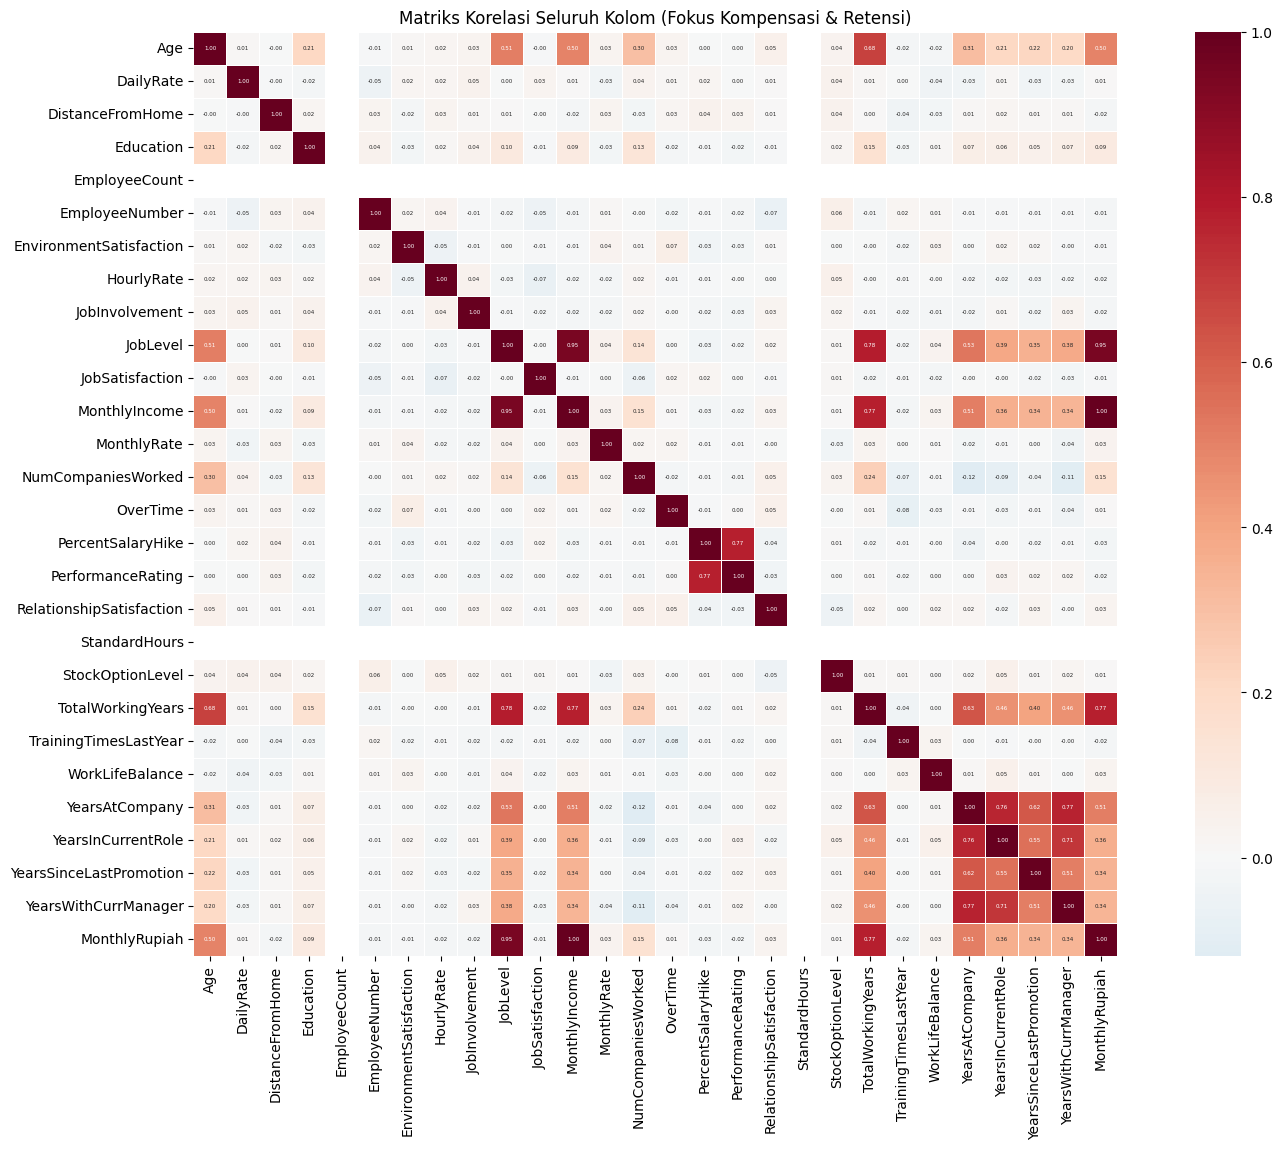

In [373]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(20, 12))

# Hitung matriks korelasi
corr_matrix = numeric_df.corr()

# Buat mask untuk menutupi bagian atas (agar tidak duplikat/simetris)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualisasi
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0,
            linewidths=0.5,
            square=True,
            annot_kws={"size": 4},)

plt.title("Matriks Korelasi Seluruh Kolom (Fokus Kompensasi & Retensi)")
plt.show()

In [374]:
df["PerformanceRating"].min()

np.int64(3)

In [375]:
df[df["PerformanceRating"] == 4]["PercentSalaryHike"].max()

np.int64(25)

# Create Synthetic Data for PerformanceRating 1 & 2

# Modeling

In [376]:
# 2. Definisikan Fitur (X) dan Target (y)
features = [
    'JobInvolvement', 'JobLevel', 
    'MonthlyIncome', 'YearsAtCompany', 'OverTime'
]
target = 'PercentSalaryHike'

X = df[features]
y = df[target]

In [377]:
# 5. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [378]:
# 5. Inisialisasi dan Train Model XGBoost (Regressor)
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    
    # KUNCI UTAMA:
    reg_lambda=150,
    colsample_bytree=0.6,
    reg_alpha=50,
    random_state=42
)

# Train model tanpa perlu feat_weights yang menyebabkan warning
model.fit(X_train, y_train)

# Cek kembali importance-nya
importance = model.feature_importances_
df_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(df_importance)

          Feature  Importance
2   MonthlyIncome    0.292528
1        JobLevel    0.230718
3  YearsAtCompany    0.199387
0  JobInvolvement    0.145067
4        OverTime    0.132300


In [379]:
df[["YearsAtCompany", "PercentSalaryHike"]].corr()

,YearsAtCompany,PercentSalaryHike
YearsAtCompany,1.000000,-0.035991
PercentSalaryHike,-0.035991,1.000000


In [380]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [381]:
# 6. Prediksi
y_pred = model.predict(X_test)

In [382]:
# 7. Evaluasi
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [383]:
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2:.2f}")

Mean Absolute Error: 3.03
R-squared Score: -0.03


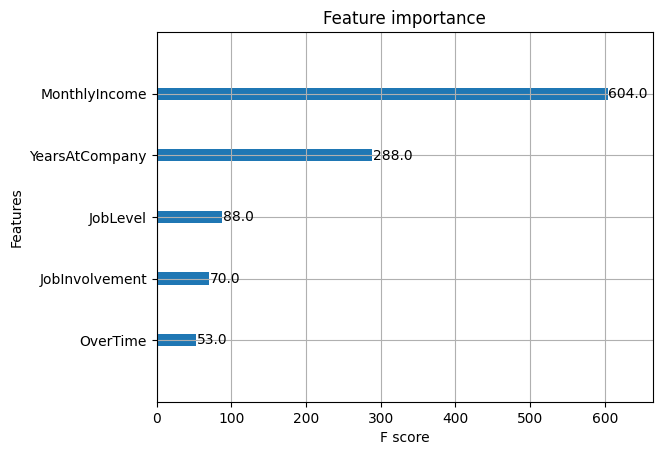

In [384]:
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=10)
plt.show()

In [385]:
importance = model.feature_importances_
df_importance = pd.DataFrame({
    "Feature": X.columns, 
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# 3. Menampilkan tabel 2 kolom
print("Tabel Fitur Importance:")
print(df_importance)

Tabel Fitur Importance:
          Feature  Importance
2   MonthlyIncome    0.292528
1        JobLevel    0.230718
3  YearsAtCompany    0.199387
0  JobInvolvement    0.145067
4        OverTime    0.132300


In [386]:
# Mendapatkan importance berdasarkan GAIN (paling akurat secara logika bisnis)
importance_gain = model.get_booster().get_score(importance_type='gain')

# Masukkan ke DataFrame
df_gain = pd.DataFrame({
    "Feature": list(importance_gain.keys()),
    "Importance": list(importance_gain.values())
}).sort_values(by="Importance", ascending=False)

print(df_gain)

          Feature  Importance
2   MonthlyIncome    2.329898
1        JobLevel    1.837599
3  YearsAtCompany    1.588056
0  JobInvolvement    1.155411
4        OverTime    1.053726
